# Import libraries

In [1]:
# File Access
from glob import glob
# Numerical tasks
from astropy import constants as const
from astropy import units as u
# Plot Generation
from astropy.io import fits
from astropy.visualization import astropy_mpl_style, simple_norm
from astropy.wcs import WCS
from matplotlib.patches import Ellipse

# Access Directory

In [2]:
telescope = 'ALMA'
source_name = '04169+2702'
base_dir = '/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks'

In [3]:
if telescope == 'ALMA':
    opacity = 1.84 * u.cm**2 / u.g 
    nu = 345 * u.GHz 
    nu_Hz = nu.to(u.Hz)
    robust_param = 0.5
if telescope == 'VLA':
    opacity = 0.13 * u.cm**2 / u.g
    nu = 33 * u.GHz 
    nu_Hz = nu.to(u.Hz)
    robust_param = 2.0
if telescope == 'SMA':
    opacity = 2.0 * u.cm**2 / u.g 
    nu = 230 * u.GHz 
    nu_Hz = nu.to(u.Hz)
    robust_param = 0.5
print(f"Opacity: {opacity:.2e}")
print(f"Frequency in Hz: {nu_Hz:.2e}")

Opacity: 1.84e+00 cm2 / g
Frequency in Hz: 3.45e+11 Hz


In [4]:
continuum_dir = os.path.join(base_dir, 'continuum_data', f'{telescope}_data')
os.chdir(continuum_dir)
continuum_files = [d for d in os.listdir(continuum_dir) if os.path.isdir(os.path.join(continuum_dir, d)) and d.endswith('selfcal.ms')]

In [5]:
source_directory = os.path.join(base_dir, source_name)
if not os.path.exists(source_directory):
    os.makedirs(source_directory)
    print(f'Directory created: {source_directory}')
else:
    print(f'Directory already exists: {source_directory}')
source_continuum_directory = os.path.join(source_directory, 'continuum', f'{telescope}')
os.chdir(source_continuum_directory)

Directory already exists: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702


In [6]:
data_directory = os.path.join(base_dir, source_name, 'continuum', f'{telescope}', 'data')
if not os.path.exists(data_directory):
    os.makedirs(data_directory)
    print(f'Data directory created: {data_directory}')
else:
    print(f'Data directory already exists: {data_directory}')
dirty_continuum_directory = os.path.join(source_directory, 'continuum', f'{telescope}', 'dirty')
if not os.path.exists(dirty_continuum_directory):
    os.makedirs(dirty_continuum_directory)
    print(f'Dirty continuum directory created: {dirty_continuum_directory}')
else:
    print(f'Dirty continuum directory already exists: {dirty_continuum_directory}')
clean_continuum_directory = os.path.join(source_directory, 'continuum', f'{telescope}', 'clean')
if not os.path.exists(clean_continuum_directory):
    os.makedirs(clean_continuum_directory)
    print(f'Clean continuum directory created: {cleam_continuum_directory}')
else:
    print(f'Clean continuum directory already exists: {clean_continuum_directory}')

Data directory already exists: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data
Dirty continuum directory already exists: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/dirty
Clean continuum directory already exists: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/clean


In [8]:
dirty_img = os.path.join(dirty_continuum_directory, f'dirty_continuum_{source_name}_taper0.5')
clean_img = os.path.join(clean_continuum_directory, f'clean_continuum_{source_name}_taper0.5')

# Split the source file ONLY WHEN NEEDED

In [21]:
from casatools import ms, table
def process_selfcal_files(base_dir, source_name):
    ms_tool = ms()
    tb = table()
    continuum_data_dir = os.path.join(base_dir, 'continuum_data', f'{telescope}_data')
    source_output_dir = os.path.join(base_dir, source_name, 'continuum', telescope, 'data')

    # Loop through all .selfcal.ms files in the continuum_data directory
    for filename in os.listdir(continuum_data_dir):
        if filename.endswith('.selfcal.ms'):
            file_path = os.path.join(continuum_data_dir, filename)

            try:
                # Open the FIELD table directly to get field names
                field_table_path = file_path + '/FIELD'
                tb.open(field_table_path)
                field_names = tb.getcol("NAME")  # Get field names directly from the FIELD table
                tb.close()

                # Check if the source name exists in the field names
                if source_name in field_names:
                    output_file_path = os.path.join(source_output_dir, f'updated_{source_name}{filename[3:]}')

                    # Use CASA `split` to split the MS based on the source name
                    print(f'Splitting {file_path} to {output_file_path}')
                    split(vis=file_path, outputvis=output_file_path, field=source_name)
                else:
                    print(f'Skipping {file_path} as the field name {source_name} does not exist.')

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
            finally:
                # Ensure MS is closed properly after each file
                ms_tool.close()

    print("Processing complete.")

In [22]:
process_selfcal_files(base_dir=base_dir, source_name=source_name)

Skipping /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe1d2cb_Xc90c_targets.selfcal.ms as the field name 04169+2702 does not exist.
Splitting /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xeee095_X4db0_targets.selfcal.ms to /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/updated_04169+2702___A002_Xeee095_X4db0_targets.selfcal.ms


2025-04-17 02:12:34	SEVERE	split::ms::open	Exception Reported: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xeee095_X4db0_targets.selfcal.ms/table.f18: No such file or directory
2025-04-17 02:12:34	SEVERE	split::::casa	Task split raised an exception of class RuntimeError with the following message: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xeee095_X4db0_targets.selfcal.ms/table.f18: No such file or directory


Error processing /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xeee095_X4db0_targets.selfcal.ms: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xeee095_X4db0_targets.selfcal.ms/table.f18: No such file or directory
Skipping /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe29133_X2cec_targets.selfcal.ms as the field name 04169+2702 does not exist.
Splitting /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe2eefc_Xcc35_targets.selfcal.ms to /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/updated_04169+2702___A002_Xe2eefc_Xcc35_targets.selfcal.ms
Error processing /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe2eefc_Xcc35_targets.selfcal.ms: Table file /lustre/cv/users/psheehan/ForNoshin/T

2025-04-17 02:12:37	SEVERE	split::ms::open	Exception Reported: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe2eefc_Xcc35_targets.selfcal.ms/OBSERVATION/table.dat does not exist
2025-04-17 02:12:37	SEVERE	split::::casa	Task split raised an exception of class RuntimeError with the following message: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe2eefc_Xcc35_targets.selfcal.ms/OBSERVATION/table.dat does not exist


Splitting /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xfa5545_X397f_targets.selfcal.ms to /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/updated_04169+2702___A002_Xfa5545_X397f_targets.selfcal.ms
Error processing /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xfa5545_X397f_targets.selfcal.ms: Table file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xfa5545_X397f_targets.selfcal.ms/SYSCAL/table.dat does not exist


...

2025-04-17 02:14:01	SEVERE	MSTransformDataHandler::makeMSBasicStructure	Exception filling the sub-tables: FiledesIO: file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe48598_Xa6e7_targets.selfcal.ms/ANTENNA/table.f0 could not be opened: No such file or directory
2025-04-17 02:14:01	SEVERE	MSTransformDataHandler::makeMSBasicStructure+	Stack Trace: 
2025-04-17 02:14:06	SEVERE	MSTransformDataHandler::makeMSBasicStructure	/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/updated_04169+2702___A002_Xe48598_Xa6e7_targets.selfcal.ms left unfinished.
2025-04-17 02:14:06	SEVERE	split::::casa	Task split raised an exception of class RuntimeError with the following message: Error creating output MS structure


Error processing /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe48598_Xa6e7_targets.selfcal.ms: Error creating output MS structure
Splitting /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe4f0a6_X2bfd_targets.selfcal.ms to /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/updated_04169+2702___A002_Xe4f0a6_X2bfd_targets.selfcal.ms


2025-04-17 02:14:36	SEVERE	MSTransformDataHandler::makeMSBasicStructure	Exception filling the sub-tables: FiledesIO: file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe4f0a6_X2bfd_targets.selfcal.ms/STATE/table.f0 could not be opened: No such file or directory
2025-04-17 02:14:36	SEVERE	MSTransformDataHandler::makeMSBasicStructure+	Stack Trace: 


Error processing /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/uid___A002_Xe4f0a6_X2bfd_targets.selfcal.ms: Error creating output MS structure
Processing complete.


2025-04-17 02:14:41	SEVERE	MSTransformDataHandler::makeMSBasicStructure	/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/updated_04169+2702___A002_Xe4f0a6_X2bfd_targets.selfcal.ms left unfinished.
2025-04-17 02:14:41	SEVERE	split::::casa	Task split raised an exception of class RuntimeError with the following message: Error creating output MS structure


# Concatenate .ms files ONLY WHEN NEEDED

In [10]:
os.chdir(data_directory)
ms_files = sorted(glob("*.ms"))
if len(ms_files) == 0:
    print("No .selfcal.ms files found in the current directory.")
else:
    concat_ms = f"{source_name}_selfcal_updated.ms"
    concat(vis=ms_files, concatvis=concat_ms)
    print(f"Concatenation complete! Output MS: {concat_ms}")

2025-04-17 02:03:45	SEVERE	concat::ms::open	Exception Reported: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/04169+2702___A002_Xe2ada9_X4275_targets.selfcal.ms/SOURCE/table.f0i: No such file or directory
2025-04-17 02:03:45	SEVERE	concat::::casa	Task concat raised an exception of class RuntimeError with the following message: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/04169+2702___A002_Xe2ada9_X4275_targets.selfcal.ms/SOURCE/table.f0i: No such file or directory


RuntimeError: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/04169+2702___A002_Xe2ada9_X4275_targets.selfcal.ms/SOURCE/table.f0i: No such file or directory

# Create Image

In [15]:
def convert_casa_to_fits(base_name):
    """
    Converts CASA files (image, model, PSF, residual) to FITS format for a given base name.

    Parameters:
    base_name (str): The base name of the CASA files to convert.
    """
    
    # Convert CASA files to FITS
    exportfits(imagename=f'{base_name}.image', fitsimage=f'{base_name}_image.fits', overwrite=True, dropdeg=True)
    exportfits(imagename=f'{base_name}.model', fitsimage=f'{base_name}_model.fits', overwrite=True, dropdeg=True)
    exportfits(imagename=f'{base_name}.psf', fitsimage=f'{base_name}_psf.fits', overwrite=True, dropdeg=True)
    exportfits(imagename=f'{base_name}.residual', fitsimage=f'{base_name}_residual.fits', overwrite=True, dropdeg=True)
    
    # If it's a clean image, export the mask as well
    if 'clean' in base_name:
        exportfits(imagename=f'{base_name}.mask', fitsimage=f'{base_name}_mask.fits', overwrite=True, dropdeg=True)
        exportfits(imagename=f'{base_name}.image.pbcor', fitsimage=f'{base_name}_image_pbcor.fits', overwrite=True, dropdeg=True)

# Dirty Image

In [784]:
inp = os.path.join(data_directory, f"{source_name}_selfcal.ms")
output = dirty_img
tclean(vis=inp,
       imagename=output,
       field= source_name,
       spw='',
       specmode='mfs',
       deconvolver='hogbom',
       gridder='standard',
       imsize=[720,720],
       cell=['0.05arcsec'],
       weighting='briggs',
       robust = 2.0, # try with 2
       threshold='',
       niter = 0,
       interactive=False)


0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2024-12-09 12:51:06	WARN	task_tclean::SIImageStore::restore (file /source/casa6/casatools/src/code/synthesis/ImagerObjects/SIImageStore.cc, line 2284)	Restoring with an empty model image. Only residuals will be processed to form the output restored image.


{'cleanstate': 'running',
 'cyclefactor': 1.0,
 'cycleiterdone': 0,
 'cycleniter': 0,
 'cyclethreshold': 0,
 'interactiveiterdone': 0,
 'interactivemode': False,
 'interactiveniter': 0,
 'interactivethreshold': 0,
 'iterdone': 0,
 'loopgain': 0,
 'maxpsffraction': 0,
 'maxpsfsidelobe': 0,
 'minpsffraction': 0,
 'niter': 0,
 'nmajordone': 1,
 'nsigma': 0.0,
 'stopcode': 3,
 'summarymajor': array([0]),
 'summaryminor': {0: {0: {0: {'iterDone': [0.0],
     'peakRes': [0.0011069696629419923],
     'modelFlux': [0.0],
     'cycleThresh': [0.0]}}}},
 'threshold': '',
 'stopDescription': 'Zero iterations performed'}

In [785]:
convert_casa_to_fits(output)

# Clean Image

In [9]:
inp = os.path.join(data_directory, f"{source_name}_selfcal.ms")
output = clean_img
for robust in [0.5]:
    tclean(
        vis=inp,
        imagename= f"{output}_{robust}",    
        field=source_name,
        spw='',
        specmode='mfs',
        deconvolver='hogbom',             
        gridder='standard',
        imsize=[720, 720],
        cell=['0.05arcsec'], 
        weighting='briggs',
        robust = robust,
        uvtaper=['0.5arcsec'],
        niter=10000,                            
        interactive=False,
        nsigma=5.0,
        threshold='',                    
        usemask='auto-multithresh',             
        noisethreshold=4.25,
        sidelobethreshold = 2.0,
        lownoisethreshold = 1.5,                    
        minbeamfrac = 0.3,
        pbcor = True)

2025-04-17 02:01:18	SEVERE	tclean::::casa	Task tclean raised an exception of class RuntimeError with the following message: Error in selectData() : Error in selectdata: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/04169+2702_selfcal.ms/SYSCAL/table.f0i: No such file or directory


RuntimeError: Error in selectData() : Error in selectdata: RegularFileIO: error in open or create of file /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04169+2702/continuum/ALMA/data/04169+2702_selfcal.ms/SYSCAL/table.f0i: No such file or directory

In [18]:
output = clean_img
if telescope == 'ALMA':
    robust_param = 0.5
if telescope == 'VLA':
    robust_param = 2.0
if telescope == 'SMA':
    robust_param = 0.5
convert_casa_to_fits(f"{output}_{robust_param}")

# Image the Source

In [19]:
# Beam info
def get_beam_info(fits_file):
    """
    Extract beam size and pixel scale information from a FITS file header.
    
    Parameters:
    fits_file (str): Path to the FITS file.
    
    Returns:
    dict: Contains beam major axis (arcsec), beam minor axis (arcsec), position angle (degrees),
          pixel scale (arcsec/pixel) for both x and y directions, and width/height of the image in pixels.
    """
    # Open the FITS file and get the header
    hdu = fits.open(fits_file)[0]
    header = hdu.header

    # Extract the beam size from the header
    bmaj = header.get('BMAJ', None)  # major axis in degrees
    bmin = header.get('BMIN', None)  # minor axis in degrees
    bpa = header.get('BPA', 0)       # position angle in degrees, default to 0 if not present

    # Convert beam size from degrees to arcseconds
    bmaj_arcsec = bmaj * 3600 if bmaj else 0
    bmin_arcsec = bmin * 3600 if bmin else 0

    # Convert pixel scale to arcseconds
    pixel_scale_x_deg = abs(header['CDELT1'])  
    pixel_scale_y_deg = abs(header['CDELT2'])  

    pixel_scale_x_arcsec = pixel_scale_x_deg * 3600
    pixel_scale_y_arcsec = pixel_scale_y_deg * 3600

    # Get the width and height of the image in pixels
    if hdu.data.ndim > 2:
        width = hdu.data.shape[3]  # Width of the image in pixels
        height = hdu.data.shape[2]  # Height of the image in pixels
    else:
        width = hdu.data.shape[1]  # Width of the image in pixels
        height = hdu.data.shape[0]  # Height of the image in pixels

    # Convert beam sizes to pixels
    beam_major_pix = bmaj_arcsec / pixel_scale_x_arcsec if bmaj else 0
    beam_minor_pix = bmin_arcsec / pixel_scale_y_arcsec if bmin else 0

    return {
        'bmaj_arcsec': bmaj_arcsec,
        'bmin_arcsec': bmin_arcsec,
        'bpa': bpa,
        'pixel_scale_x_arcsec': pixel_scale_x_arcsec,
        'pixel_scale_y_arcsec': pixel_scale_y_arcsec,
        'width': width,
        'height': height,
        'beam_major_pix': beam_major_pix,
        'beam_minor_pix': beam_minor_pix
    }

In [20]:
# Get beam information from the FITS file
beam_info = get_beam_info(f'{clean_img}_{robust_param}_image_pbcor.fits')

In [27]:
def plot_source(fits_file, source_name, d_AU, beam_info, source_center_pixels, zoom_margin):
    """
    Plot a FITS image with the beam size and scale bar, centering based on pixel coordinates.
    """
    # Open the FITS file and extract data and WCS
    hdu = fits.open(fits_file)[0]
    wcs = WCS(hdu.header)

    if hdu.data.ndim > 2:
        data_to_plot = hdu.data[0, 0, :, :]
        width = hdu.data.shape[3]
        height = hdu.data.shape[2]
    else:
        data_to_plot = hdu.data[:, :]
        width = hdu.data.shape[1]
        height = hdu.data.shape[0]

    # Extract the source center in pixels
    x_center, y_center = source_center_pixels

    # Define zoom limits with the provided source center and margin
    zoom_width = int((width * zoom_margin) / 2)
    zoom_height = int((height * zoom_margin) / 2)

    xmin = max(0, x_center - zoom_width)
    xmax = min(width, x_center + zoom_width)
    ymin = max(0, y_center - zoom_height)
    ymax = min(height, y_center + zoom_height)

    # Set up the plot
    plt.style.use(astropy_mpl_style)
    fig, ax = plt.subplots(subplot_kw={'projection': wcs})
    norm = simple_norm(data_to_plot, 'linear')
    if telescope == 'ALMA' or 'SMA':
        clr = 'white'
    if telescope == 'VLA':
        clr = 'black'

    # Display the image
    im = ax.imshow(data_to_plot, origin='lower', cmap='jet', norm=norm)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Add color bar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label("Flux (Jy/beam)", fontsize=12)

    # Add source name
    ax.text(0.05, 0.95, source_name, transform=ax.transAxes, fontsize=12, color=clr, ha='left', va='top')

    # Adjust beam size to the zoomed region
    zoom_width_actual = xmax - xmin
    zoom_height_actual = ymax - ymin
    beam_ellipse = Ellipse(
        xy=(xmin + 0.1 * zoom_width_actual, ymin + 0.1 * zoom_height_actual),  # Adjusted for zoom
        width=beam_info['beam_major_pix'],
        height=beam_info['beam_minor_pix'],
        edgecolor=clr, facecolor=clr,
        lw=2, linestyle='-', angle=90 + beam_info['bpa']
    )
    ax.add_patch(beam_ellipse)

    # Calculate the scale bar in pixels relative to the zoomed region
    scale_bar = 100  # in AU
    angular_size_arcsec = (206265 * scale_bar / d_AU)  # Convert AU to arcseconds
    scale_bar_pix = angular_size_arcsec / beam_info['pixel_scale_x_arcsec'] 
    scale_bar_pix = scale_bar_pix.value  
    
    # Define coordinates for the scale bar in the lower right corner
    scale_bar_x_start = xmin + 0.8 * zoom_width_actual  # Adjusted for zoom
    scale_bar_x_end = scale_bar_x_start + scale_bar_pix  # Add scale_bar_pix directly
    scale_bar_y = ymin + 0.1 * zoom_height_actual  # Adjusted for zoom
    
    # Draw the scale bar
    ax.plot([scale_bar_x_start, scale_bar_x_end], [scale_bar_y, scale_bar_y], color=clr, lw=4)
    
    # Add text below the scale bar
    ax.text((scale_bar_x_start + scale_bar_x_end) / 2, scale_bar_y - 0.03 * zoom_height_actual,
            f"{scale_bar} AU", color=clr, fontsize=10, ha='center', va='center')

    # Disable the grid
    ax.grid(False)

    # Set axis labels
    ax.set_xlabel('RA (J2000)')
    ax.set_ylabel('Dec (J2000)')

    # Add a title to the plot
    wvl = "0.87mm" if telescope == "ALMA" else "9mm" if telescope == "VLA" else "1.3mm" if telescope == "SMA" else ""
    title_text = f"{source_name} {wvl}"
    ax.set_title(title_text, fontsize=14, color='black')

    # Save the plot
    plt.savefig(f'{source_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

Set OBSGEO-B to    19.947177 from OBSGEO-[XYZ].
Set OBSGEO-H to     6578.484 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


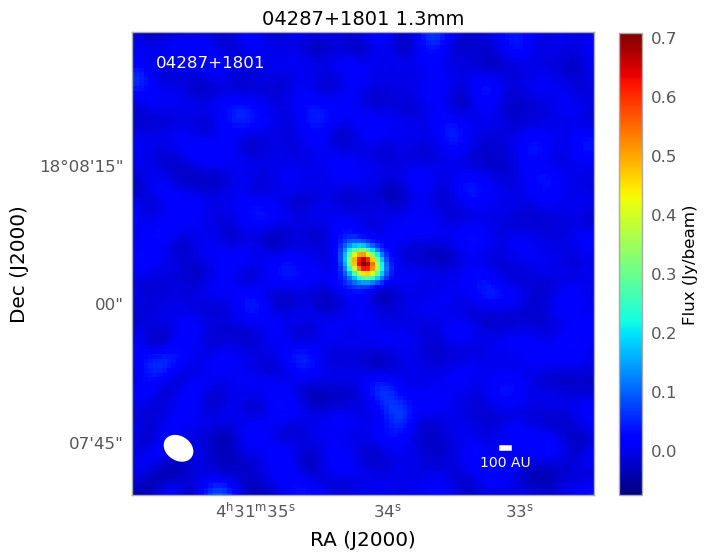

In [30]:
# Define a margin to zoom in 
d_AU = (140 * u.pc).to(u.au)
zoom_margin = 0.2
source_center_pixels = (247, 249)
plot_source(f'{clean_img}_{robust_param}_image_pbcor.fits', source_name=source_name, d_AU=d_AU, beam_info=beam_info,
    source_center_pixels=source_center_pixels, zoom_margin=zoom_margin)

# Run imfit/imstat

In [8]:
inp_file = os.path.join(clean_continuum_directory, f'{clean_img}_{robust_param}.image')
region = f'{clean_continuum_directory}/my_region'
imfit_result = imfit(imagename = inp_file, region = region)
stats = imstat(imagename= inp_file, region = region)

# Identify Source Center and Distance from the Phase Center

In [9]:
from astropy.coordinates import Angle
def get_source_center(imfit_result):
    " Extracts and formats RA and Dec from the imfit result."
    ra_center = imfit_result['results']['component0']['shape']['direction']['m0']['value'] # in rad
    dec_center = imfit_result['results']['component0']['shape']['direction']['m1']['value'] # in rad
    ra_degrees = ra_center * u.rad.to(u.deg)
    dec_degrees = dec_center * u.rad.to(u.deg)

    # Format as HH:MM:SS.SS for RA and DD:MM:SS.SS for Dec
    ra_formatted = Angle(ra_degrees, unit=u.deg).to_string(unit=u.hourangle, precision=2)
    dec_formatted = Angle(dec_degrees, unit=u.deg).to_string(unit=u.deg, alwayssign=True, precision=2)

    return ra_formatted, dec_formatted

In [10]:
ra_center, dec_center = get_source_center(imfit_result)
print('Source Center: ', ra_center, dec_center)

Source Center:  4h31m34.18s +18d08m04.48s


In [11]:
from casatools import table
def extract_field_center(vis_path):
    " Extract the field center (RA and Dec) from the metadata of a .ms file."
    tb = table()
    tb.open(os.path.join(vis_path, 'FIELD'))
    
    # Read the first (and only) field's name and phase center
    field_names = tb.getcol('NAME')
    phase_centers = tb.getcol('PHASE_DIR')  
    tb.close()

    field_name = field_names[0]
    ra_radians = phase_centers[0, 0]
    dec_radians = phase_centers[1, 0]

    # Convert RA and Dec to formatted strings
    ra_hms = Angle(ra_radians, unit='rad').to_string(unit='hourangle', precision=2)
    dec_dms = Angle(dec_radians, unit='rad').to_string(unit='deg', alwayssign=True, precision=2)

    return {"Field Name": field_name, "RA": ra_hms[0], "Dec": dec_dms[0]}

In [12]:
ALMA_vis_path = os.path.join(data_directory, f'{source_name}_selfcal.ms')
VLA_vis_path = os.path.join(source_directory, 'continuum', 'VLA', 'data', f'{source_name}_selfcal.ms')
alma_field = extract_field_center(ALMA_vis_path)
vla_field = extract_field_center(VLA_vis_path)
print('ALMA Field: ', alma_field)
print('VLA Field: ', vla_field)

2025-01-09 08:37:50	SEVERE	open::/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04287+1801/continuum/SMA/data/04287+1801_selfcal.ms/FIELD	Exception Reported: Table /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04287+1801/continuum/SMA/data/04287+1801_selfcal.ms/FIELD does not exist


RuntimeError: Table /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04287+1801/continuum/SMA/data/04287+1801_selfcal.ms/FIELD does not exist

In [509]:
from astropy.coordinates import SkyCoord
coord1 = SkyCoord(ra_center, dec_center, frame='icrs')
ALMA_coord2 = SkyCoord(alma_field['RA'], alma_field['Dec'], frame='icrs')
VLA_coord2 = SkyCoord(vla_field['RA'], vla_field['Dec'], frame='icrs')

# Calculate the angular separation in arcseconds
alma_angular_distance = coord1.separation(ALMA_coord2).arcsecond
vla_angular_distance = coord1.separation(VLA_coord2).arcsecond

print(f"DeltaPhiA: {alma_angular_distance:.3f} arcseconds")
print(f"DeltaPhiV: {vla_angular_distance:.3f} arcseconds")

DeltaPhiA: 7.769 arcseconds
DeltaPhiV: 7.769 arcseconds


# Calculate Flux

In [13]:
def cal_flux (imfit_result, stats):
    " Calculate total flux and peak flux using imfit and imstat, returning results as a dictionary."
    
    flux = imfit_result['results']['component0']['flux']['value'][0] # in Jy
    flux_err = imfit_result['results']['component0']['flux']['error'][0]  # in Jy

    # Peak Flux
    imfit_peak_flux = imfit_result['results']['component0']['peak']['value']  
    imfit_peak_flux_error = imfit_result['results']['component0']['peak']['error'] 
    imstat_peak_flux = stats['max'][0]  

    result = {
        "Flux (Jy)": flux,
        "Flux Error (Jy)": flux_err,
        "Imfit Peak Flux (Jy/beam)": imfit_peak_flux,
        "Imfit Peak Flux Error (Jy/beam)": imfit_peak_flux_error,
        "Imstat Peak Flux (Jy/beam)": imstat_peak_flux
    }
    return result

In [14]:
flux_result = cal_flux(imfit_result, stats)
print(f"Total Flux: {flux_result['Flux (Jy)']*1000:.2f} ± {flux_result['Flux Error (Jy)']*1000:.2f} mJy")
print(f"Imfit Peak Flux: {flux_result['Imfit Peak Flux (Jy/beam)']*1000:.2f} ± {flux_result['Imfit Peak Flux Error (Jy/beam)']*1000:.2f} mJy/beam")
print(f"Imstat Peak Flux: {flux_result['Imstat Peak Flux (Jy/beam)']*1000:.2f} mJy/beam")

Total Flux: 774.62 ± 20.13 mJy
Imfit Peak Flux: 701.53 ± 10.81 mJy/beam
Imstat Peak Flux: 705.89 mJy/beam


# Calculate Mass

In [15]:
# Constants
h = const.h.to(u.erg * u.s)  # Planck constant 
c = const.c.to(u.cm / u.s)  # Speed of light 
k_B = const.k_B.to(u.erg / u.K)  # Boltzmann constant 
T_dust = 43 * u.K 
d = (140 * u.pc).to(u.cm)
d_pc = (140 * u.pc)
print(f"Planck constant (h): {h}")
print(f"Speed of light (c): {c}")
print(f"Boltzmann constant (k_B): {k_B}")
print(f"Dust temperature (T_dust): {T_dust}")
print(f"Distance (d): {d}")

Planck constant (h): 6.62607015e-27 erg s
Speed of light (c): 29979245800.0 cm / s
Boltzmann constant (k_B): 1.380649e-16 erg / K
Dust temperature (T_dust): 43.0 K
Distance (d): 4.3199486140879136e+20 cm


$$
M = \frac{d^2 \cdot F_\nu}{\kappa_\nu \cdot B_\nu}
$$

To propagate the uncertainty in mass:

$$
\sigma_M = \sqrt{\left( \frac{\partial M}{\partial d} \cdot \sigma_d \right)^2 + \left( \frac{\partial M}{\partial F_\nu} \cdot \sigma_{F_\nu} \right)^2}
$$

Partial derivative with respect to distance:

$$
\frac{\partial M}{\partial d} = \frac{2d \cdot F_\nu}{\kappa_\nu \cdot B_\nu}
$$

Partial derivative with respect to flux:

$$
\frac{\partial M}{\partial F_\nu} = \frac{d^2}{\kappa_\nu \cdot B_\nu}
$$

Total uncertainty in mass:

$$
\sigma_M = \sqrt{\left( \frac{2d \cdot F_\nu}{\kappa_\nu \cdot B_\nu} \cdot \sigma_d \right)^2 + \left( \frac{d^2}{\kappa_\nu \cdot B_\nu} \cdot \sigma_{F_\nu} \right)^2}
$$


In [16]:
from astropy.modeling.models import BlackBody
blackbody = BlackBody(temperature=T_dust) # BlackBody object
B_nu = blackbody(nu_Hz)
print(f"B_nu: {B_nu}")

B_nu: 6.130017467332396e-13 erg / (Hz s sr cm2)


In [17]:
from astropy.constants import M_earth
def cal_mass(flux, calculated_flux_err, dist, opacity, B_nu):
    " Calculates Mass with uncertainty. Flux and flux error must be in cgs."
    M = (dist**2 * flux)/(opacity * B_nu)
   
    # uncerainty calculation
    partial_dist = (2 * d * flux) / (opacity * B_nu)
    partial_f = (d ** 2) / (opacity * B_nu)
    
    sigma_dist = 0.1 * d  # 10% uncertainty in distance value
    sigma_f =  np.sqrt(calculated_flux_err**2 + (0.1 * flux) **2) # 10% flux uncertainty from calibration
    
    sigma_M = np.sqrt((partial_dist * sigma_dist)**2 + (partial_f * sigma_f)**2)
    
    mass_earth = (M/u.sr).to(u.M_earth)
    sigma_M_earth = (sigma_M/u.sr).to(u.M_earth)

    mass_result = f"{mass_earth.value:.3f} ± {sigma_M_earth.value:.3f}"

    return mass_result

In [18]:
flux_jy = flux_result['Flux (Jy)'] * u.Jy
flux_cgs = flux_jy.to(u.erg / (u.s * u.cm**2 * u.Hz))
flux_err_jy = flux_result['Flux Error (Jy)'] * u.Jy
flux_err_cgs = flux_err_jy.to(u.erg / (u.s * u.cm**2 * u.Hz))
mass_result = cal_mass(flux_cgs, flux_err_cgs, d, opacity, B_nu)
print("Mass (Earth Mass): ", mass_result)

Mass (Earth Mass):  197.433 ± 44.445


# Calculate Radius

### Beam-Limited Deconvolution and Error Propagation

When the source is smaller than the beam, the deconvolved major and minor axes are approximated as:

$$
\text{deconv\_major\_axis} = \frac{\text{beam\_major\_axis}}{\sqrt{\text{SNR}}}
$$

$$
\text{deconv\_minor\_axis} = \frac{\text{beam\_minor\_axis}}{\sqrt{\text{SNR}}}
$$

#### Error Propagation for Deconvolved Axes

The propagated error for the deconvolved major axis is:

$$
\sigma_{\text{deconv\_major\_axis}} = \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_major\_axis}}{\text{SNR}^{1.5}}
$$

And for the minor axis:

$$
\sigma_{\text{deconv\_minor\_axis}} = \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_minor\_axis}}{\text{SNR}^{1.5}}
$$

#### Final Error Propagation Formula

For completeness, the error propagation formula is:

$$
\sigma_{\text{deconv\_major\_axis}} = \sqrt{\left( \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_major\_axis}}{\text{SNR}^{1.5}} \right)^2}
$$

$$
\sigma_{\text{deconv\_minor\_axis}} = \sqrt{\left( \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_minor\_axis}}{\text{SNR}^{1.5}} \right)^2}
$$


In [516]:
def cal_snr():
    " Calculate SNR of the image"
    peak_signal = flux_result['Imfit Peak Flux (Jy/beam)']
    peak_signal_err = flux_result['Imfit Peak Flux Error (Jy/beam)']
    residual_stats = imstat(imagename=f'{clean_img}_{robust_param}.residual')
    rms = stats['rms'][0]  # RMS value
    snr = peak_signal / rms
    snr_err = snr * (peak_signal_err / peak_signal)
    return rms, snr, snr_err

In [517]:
rms, snr, snr_err = cal_snr()
print("rms (Jy): ", rms)
print("snr: ", snr)
print("snr: ", snr_err)

rms (Jy):  0.0010256714211317281
snr:  6.846293832628413
snr:  0.1645617748490799


In [518]:
def cal_radius(imfit_result, is_upper_limit = False):
    " Calculates Radius of the disk (region) in AU."
    
    # Observed Image Size (Convolved)
    major_axis = imfit_result['results']['component0']['shape']['majoraxis']['value']  # in arcsec
    minor_axis = imfit_result['results']['component0']['shape']['minoraxis']['value']  # in arcsec

    # Beam Size (Major and Minor Axes in arcseconds)
    beam_major_axis = beam_info['bmaj_arcsec'] 
    beam_minor_axis = beam_info['bmin_arcsec']

    # Deconvolve the source size (Major and Minor axes)
    if major_axis**2 > beam_major_axis**2 and minor_axis**2 > beam_minor_axis**2:
        # Deconvolution is possible, so we use the deconvolved values
        deconv_major_axis = imfit_result['deconvolved']['component0']['shape']['majoraxis']['value'] # in arcsec
        deconv_minor_axis = imfit_result['deconvolved']['component0']['shape']['minoraxis']['value'] # in arcsec
        deconv_major_axis_err = imfit_result['deconvolved']['component0']['shape']['majoraxiserror']['value']  # error in arcsec
        deconv_minor_axis_err = imfit_result['deconvolved']['component0']['shape']['minoraxiserror']['value']  # error in arcsec
    else:
        # If the source size is smaller than the beam, use beam-limited deconvolution
        is_upper_limit = True
        deconv_major_axis = beam_major_axis / np.sqrt(snr)
        deconv_minor_axis = beam_minor_axis / np.sqrt(snr)
        # Error propagation for deconvolved major and minor axes (based on SNR error)
        deconv_major_axis_err = np.sqrt((0.5 * snr_err * beam_major_axis / snr**1.5)**2)
        deconv_minor_axis_err = np.sqrt((0.5 * snr_err * beam_minor_axis / snr**1.5)**2)

    # Calculate intrinsic radius (AU) and its uncertainty
    intrinsic_radius_arcsec = deconv_major_axis / 2
    intrinsic_radius_err_arcsec = deconv_major_axis_err / 2
    intrinsic_radius_au = intrinsic_radius_arcsec * d_pc.value
    intrinsic_radius_err_au = intrinsic_radius_err_arcsec * d_pc.value

    # Prepare results
    result = {
        "Radius (AU)": f"{intrinsic_radius_au:.2f} ± {intrinsic_radius_err_au:.2f}",
        "Deconvolved Size (arcsec)": f"{deconv_major_axis:.2f} x {deconv_minor_axis:.2f}",
        "Is Upper Limit": is_upper_limit
    }

    return result

In [519]:
radius_result = cal_radius(imfit_result)
print(radius_result)

{'Radius (AU)': '14.32 ± 1.43', 'Deconvolved Size (arcsec)': '0.20 x 0.16', 'Is Upper Limit': False}


# Calculate Inclination

### Inclination Angle Calculation

The inclination angle \( i \) is calculated as:

$$
i = \cos^{-1} \left( \frac{\text{deconv\_minor\_axis}}{\text{deconv\_major\_axis}} \right)
$$

### Error Propagation for Inclination Angle

We propagate the errors in both the **deconvolved minor axis** \( x = \text{deconv\_minor\_axis} \) and the **deconvolved major axis** \( y = \text{deconv\_major\_axis} \).

The general error propagation formula is:

$$
\sigma_i = \sqrt{\left( \frac{\partial i}{\partial x} \cdot \sigma_x \right)^2 + \left( \frac{\partial i}{\partial y} \cdot \sigma_y \right)^2}
$$

Where:
- \( \sigma_x \) is the error in the deconvolved minor axis \( x = \text{deconv\_minor\_axis} \),
- \( \sigma_y \) is the error in the deconvolved major axis \( y = \text{deconv\_major\_axis} \).

#### Partial Derivatives

The partial derivative with respect to the minor axis \( x \) is:

$$
\frac{\partial i}{\partial x} = -\frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{1}{y}
$$

The partial derivative with respect to the major axis \( y \) is:

$$
\frac{\partial i}{\partial y} = \frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{x}{y^2}
$$

#### Final Error Propagation Formula

The final error in the inclination \( \sigma_i \) is:

$$
\sigma_i = \sqrt{\left( \frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{\sigma_x}{y} \right)^2 + \left( \frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{x \cdot \sigma_y}{y^2} \right)^2}
$$

Where:
- x = deconv minor axis
- y = deconv major axis
- sigma_x = deconv minor axis error
- sigma_y = deconv major axis error

In [9]:
def cal_i(imfit_result):
    deconv_major_axis = imfit_result['deconvolved']['component0']['shape']['majoraxis']['value'] # in arcsec
    deconv_minor_axis = imfit_result['deconvolved']['component0']['shape']['minoraxis']['value'] # in arcsec
    deconv_major_axis_err = imfit_result['deconvolved']['component0']['shape']['majoraxiserror']['value']  # error in arcsec
    deconv_minor_axis_err = imfit_result['deconvolved']['component0']['shape']['minoraxiserror']['value']  # error in arcsec

    i = np.degrees(np.arccos(deconv_minor_axis / deconv_major_axis))

    # Uncertainty Calculation
    minor_major_ratio = deconv_minor_axis / deconv_major_axis
    denominator = np.sqrt(1 - minor_major_ratio**2)
    
    # Partial derivatives
    partial_minor_axis = -1 / (denominator * deconv_major_axis)
    partial_major_axis = minor_major_ratio / (denominator * deconv_major_axis)
    
    # Propagating the errors
    inclination_err = np.degrees(np.sqrt(
        (partial_minor_axis * deconv_minor_axis_err)**2 +
        (partial_major_axis * deconv_major_axis_err)**2
    ))

    # Extract the deconvolved position angle
    deconv_position_angle = imfit_result['deconvolved']['component0']['shape']['positionangle']['value']  # in degrees
    deconv_position_angle_err = imfit_result['deconvolved']['component0']['shape']['positionangleerror']['value'] # in degrees

    # Return results
    inclination_result = f"{i:.2f} ± {inclination_err:.2f}"
    position_angle_result = f"{deconv_position_angle:.2f} ± {deconv_position_angle_err:.2f}"
    return inclination_result, position_angle_result

In [10]:
i_result, pa_result = cal_i(imfit_result)
print(i_result, pa_result)

71.15 ± 0.59 68.40 ± 0.61


# Save as a .csv file

In [522]:
import pandas as pd

# Define the columns for the DataFrame
columns = [
    "Source", "RA (J2000)", "Dec (J2000)", "ALMA Field", "Delta_phiA (arcsec)", "VLA Field", "Delta_phiV (arcsec)",
    "Flux (mJy)", "Imfit Peak Flux (mJy/beam)", "Imstat Peak Flux (mJy/beam)", "RMS (µJy)", "Deconvolved Size (arcsec x arcsec)", "PA (degrees)",
    "Mass (Earth Mass)", "Radius (AU)", "Upper Limit", "i (degrees)"]

# Specify the file name based on the telescope
if telescope == 'ALMA':
    output_file = os.path.join(continuum_dir, "ALMA_Measurements.csv")
elif telescope == 'VLA':
    output_file = os.path.join(continuum_dir, "VLA_Measurements.csv")
else:
    raise ValueError("Unsupported telescope. Only 'ALMA' and 'VLA' are allowed.")

# Check if the file already exists
if os.path.exists(output_file):
    # Load the existing file
    df = pd.read_csv(output_file)
else:
    # Create a new DataFrame if the file doesn't exist
    df = pd.DataFrame(columns=columns)

# Define the source-specific information
# Define the source-specific information, rounded to 3 decimal places
source_info = {
    "Source": f'{source_name}',
    "RA (J2000)": ra_center,  
    "Dec (J2000)": dec_center,  
    "ALMA Field": alma_field['Field Name'],
    "Delta_phiA (arcsec)": round(alma_angular_distance, 1),
    "VLA Field": vla_field['Field Name'],
    "Delta_phiV (arcsec)": round(vla_angular_distance, 1),
    "Flux (mJy)": f"{round(flux_result['Flux (Jy)'] * 1000, 2)} ± {round(flux_result['Flux Error (Jy)'] * 1000, 2)}",
    "Imfit Peak Flux (mJy/beam)": f"{round(flux_result['Imfit Peak Flux (Jy/beam)'] * 1000, 2)} ± {round(flux_result['Imfit Peak Flux Error (Jy/beam)'] * 1000, 2)}",
    "Imstat Peak Flux (mJy/beam)": round(flux_result['Imstat Peak Flux (Jy/beam)'] * 1000, 2),
    "RMS (µJy)": f"{round(rms * 1e6, 1)}",
    "Deconvolved Size (arcsec x arcsec)": radius_result['Deconvolved Size (arcsec)'],
    "PA (degrees)": pa_result,
    "Mass (Earth Mass)": mass_result,
    "Radius (AU)": radius_result['Radius (AU)'],
    "Upper Limit": radius_result['Is Upper Limit'],
    "i (degrees)": i_result
}

# Check if the source already exists in the DataFrame
if source_name in df["Source"].values:
    # Update the row corresponding to the source
    df.loc[df["Source"] == source_name, list(source_info.keys())] = pd.DataFrame([source_info]).values[0]
else:
    # Append the new source information to the DataFrame
    df = pd.concat([df, pd.DataFrame([source_info])], ignore_index=True)

# Save the updated DataFrame back to the file
df.to_csv(output_file, index=False)

print(f"File '{output_file}' has been updated with the source information.")

File '/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/ALMA_Measurements.csv' has been updated with the source information.


# Spectral Index Calculation

Spectral Index (2 points): α = 3.24
Spectral Index (3 points): α = 3.28


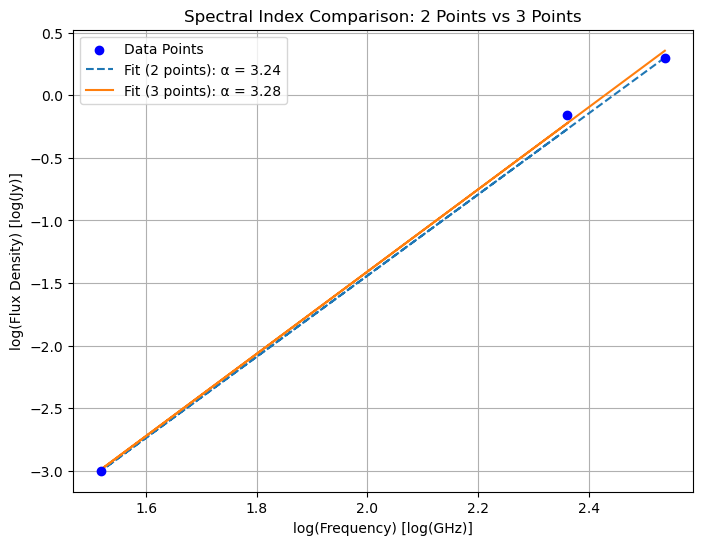

In [19]:
# Frequencies (in GHz) and fluxes (in Jy)
frequencies = np.array([345, 33, 230])  
fluxes = np.array([2.0, 0.0083, 0.7])     

# Convert frequencies and fluxes to log-log space
log_frequencies = np.log10(frequencies)
log_fluxes = np.log10(fluxes)

# Fit using the first two points
fit_two = np.polyfit(log_frequencies[:2], log_fluxes[:2], 1)
alpha_two = fit_two[0]  # Slope of the line
intercept_two = fit_two[1]

# Fit using all three points
fit_three = np.polyfit(log_frequencies, log_fluxes, 1)
alpha_three = fit_three[0]  # Slope of the line
intercept_three = fit_three[1]

# Generate fitted lines for plotting
fit_line_two = alpha_two * log_frequencies + intercept_two
fit_line_three = alpha_three * log_frequencies + intercept_three

# Print the spectral indices
print(f"Spectral Index (2 points): α = {alpha_two:.2f}")
print(f"Spectral Index (3 points): α = {alpha_three:.2f}")

# Plotting
plt.figure(figsize=(8, 6))

# Data points
plt.scatter(log_frequencies, log_fluxes, color='blue', label='Data Points', zorder=5)

# Fits
plt.plot(log_frequencies, fit_line_two, label=f'Fit (2 points): α = {alpha_two:.2f}', linestyle='--')
plt.plot(log_frequencies, fit_line_three, label=f'Fit (3 points): α = {alpha_three:.2f}', linestyle='-')

# Labels and legend
plt.xlabel('log(Frequency) [log(GHz)]')
plt.ylabel('log(Flux Density) [log(Jy)]')
plt.title('Spectral Index Comparison: 2 Points vs 3 Points')
plt.legend()
plt.grid(True)
plt.show()

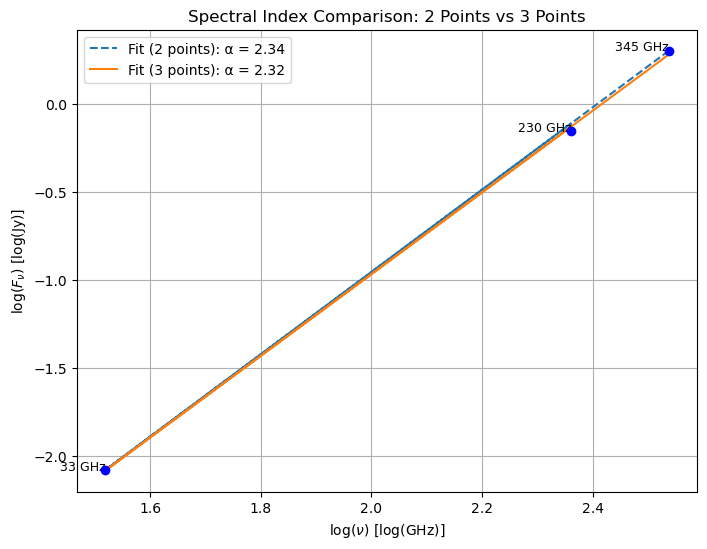

In [7]:
# Frequencies (in GHz) and fluxes (in Jy)
frequencies = np.array([345, 33, 230])  
fluxes = np.array([2.0, 0.0083, 0.7])     

# Convert frequencies and fluxes to log-log space
log_frequencies = np.log10(frequencies)
log_fluxes = np.log10(fluxes)

# Fit using the first two points
fit_two = np.polyfit(log_frequencies[:2], log_fluxes[:2], 1)
alpha_two = fit_two[0]  # Slope of the line
intercept_two = fit_two[1]

# Fit using all three points
fit_three = np.polyfit(log_frequencies, log_fluxes, 1)
alpha_three = fit_three[0]  # Slope of the line
intercept_three = fit_three[1]

# Generate fitted lines for plotting
fit_line_two = alpha_two * log_frequencies + intercept_two
fit_line_three = alpha_three * log_frequencies + intercept_three

# Plotting
plt.figure(figsize=(8, 6))

# Data points with frequency labels
for freq, log_freq, log_flux in zip(frequencies, log_frequencies, log_fluxes):
    plt.scatter(log_freq, log_flux, color='blue', zorder=5)
    plt.text(log_freq, log_flux, f'{freq} GHz', fontsize=9, ha='right')

# Fits
plt.plot(log_frequencies, fit_line_two, label=f'Fit (2 points): α = {alpha_two:.2f}', linestyle='--')
plt.plot(log_frequencies, fit_line_three, label=f'Fit (3 points): α = {alpha_three:.2f}', linestyle='-')

# Labels and legend
plt.xlabel(r'$\log(\nu)$ [log(GHz)]')  # nu for frequency
plt.ylabel(r'$\log(F_\nu)$ [log(Jy)]')  # F_nu for flux
plt.title('Spectral Index Comparison: 2 Points vs 3 Points')
plt.legend()
plt.grid(True)
plt.show()

Spectral Index (2 points): α = 3.24 ± 0.00
Spectral Index (3 points): α = 3.28 ± 0.11


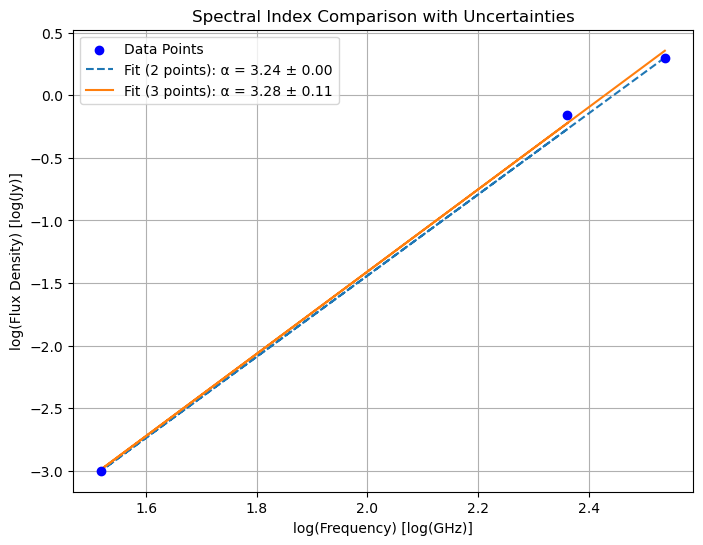

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Frequencies (in GHz) and fluxes (in Jy)
 

# Convert frequencies and fluxes to log-log space
log_frequencies = np.log10(frequencies)
log_fluxes = np.log10(fluxes)

# Fit using the first two points (linregress provides slope and its error)
slope_two, intercept_two, _, _, stderr_two = linregress(log_frequencies[:2], log_fluxes[:2])

# Fit using all three points
slope_three, intercept_three, _, _, stderr_three = linregress(log_frequencies, log_fluxes)

# Print results
print(f"Spectral Index (2 points): α = {slope_two:.2f} ± {stderr_two:.2f}")
print(f"Spectral Index (3 points): α = {slope_three:.2f} ± {stderr_three:.2f}")

# Generate fitted lines for plotting
fit_line_two = slope_two * log_frequencies + intercept_two
fit_line_three = slope_three * log_frequencies + intercept_three

# Plotting
plt.figure(figsize=(8, 6))

# Data points
plt.scatter(log_frequencies, log_fluxes, color='blue', label='Data Points', zorder=5)

# Fits
plt.plot(log_frequencies, fit_line_two, label=f'Fit (2 points): α = {slope_two:.2f} ± {stderr_two:.2f}', linestyle='--')
plt.plot(log_frequencies, fit_line_three, label=f'Fit (3 points): α = {slope_three:.2f} ± {stderr_three:.2f}', linestyle='-')

# Labels and legend
plt.xlabel('log(Frequency) [log(GHz)]')
plt.ylabel('log(Flux Density) [log(Jy)]')
plt.title('Spectral Index Comparison with Uncertainties')
plt.legend()
plt.grid(True)
plt.show()


Spectral Index: α = 3.30 ± 0.43


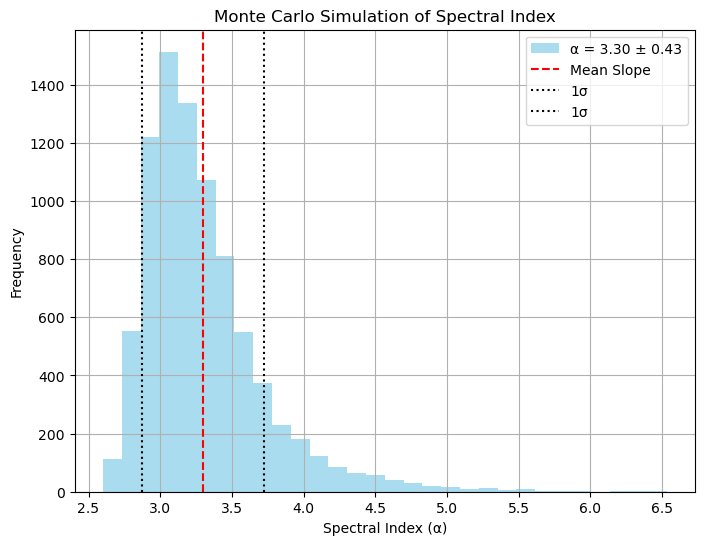

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Frequencies (in GHz), fluxes (in Jy), and flux uncertainties (in Jy)
frequencies = np.array([345, 33, 230])  
fluxes = np.array([2.0, 0.001, 0.7])     
flux_errors = np.array([0.08, 0.001, 0.02])  # Replace with your flux uncertainties

# Convert frequencies to log space
log_frequencies = np.log10(frequencies)

# Monte Carlo simulation parameters
num_simulations = 10000
slopes = []

# Monte Carlo iterations
for _ in range(num_simulations):
    # Sample fluxes from Gaussian distributions
    sampled_fluxes = np.random.normal(fluxes, flux_errors)
    
    # Ensure sampled fluxes are positive
    if np.any(sampled_fluxes <= 0):
        continue  # Skip this iteration if any flux is non-positive

    # Convert sampled fluxes to log space
    log_sampled_fluxes = np.log10(sampled_fluxes)
    
    # Perform linear fit (log-log space)
    slope, _ = np.polyfit(log_frequencies, log_sampled_fluxes, 1)
    slopes.append(slope)

# Convert slopes to a numpy array for statistics
slopes = np.array(slopes)

# Calculate mean and 1σ uncertainty of the slopes
mean_slope = np.mean(slopes)
std_slope = np.std(slopes)

# Print results
print(f"Spectral Index: α = {mean_slope:.2f} ± {std_slope:.2f}")

# Plot the histogram of slopes
plt.figure(figsize=(8, 6))
plt.hist(slopes, bins=30, alpha=0.7, color='skyblue', label=f'α = {mean_slope:.2f} ± {std_slope:.2f}')
plt.axvline(mean_slope, color='red', linestyle='--', label='Mean Slope')
plt.axvline(mean_slope - std_slope, color='black', linestyle=':', label='1σ')
plt.axvline(mean_slope + std_slope, color='black', linestyle=':', label='1σ')
plt.xlabel('Spectral Index (α)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation of Spectral Index')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Convert frequencies to log space
log_frequencies = np.log10(frequencies)

# Monte Carlo simulation parameters
num_simulations = 10000
slopes = []

# Monte Carlo iterations
for _ in range(num_simulations):
    # Sample fluxes from Gaussian distributions
    sampled_fluxes = np.random.normal(fluxes, flux_errors)
    
    # Ensure sampled fluxes are positive
    if np.any(sampled_fluxes <= 0):
        continue  # Skip this iteration if any flux is non-positive

    # Convert sampled fluxes to log space
    log_sampled_fluxes = np.log10(sampled_fluxes)
    
    # Perform linear fit (log-log space)
    slope, _ = np.polyfit(log_frequencies, log_sampled_fluxes, 1)
    slopes.append(slope)

# Convert slopes to a numpy array for statistics
slopes = np.array(slopes)

# Calculate mean and 1σ uncertainty of the slopes
mean_slope = np.mean(slopes)
std_slope = np.std(slopes)

# Print results
print(f"Spectral Index: α = {mean_slope:.2f} ± {std_slope:.2f}")

# Plot the histogram of slopes
plt.figure(figsize=(8, 6))
plt.hist(slopes, bins=30, alpha=0.7, color='skyblue', label=f'α = {mean_slope:.2f} ± {std_slope:.2f}')
plt.axvline(mean_slope, color='red', linestyle='--', label='Mean Slope')
plt.axvline(mean_slope - std_slope, color='black', linestyle=':', label='1σ')
plt.axvline(mean_slope + std_slope, color='black', linestyle=':', label='1σ')
plt.xlabel('Spectral Index (α)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation of Spectral Index')
plt.legend()
plt.grid(True)
plt.show()